In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import utils

In [3]:
df = pd.read_csv("../data/benin-malanville.csv")

In [4]:
df.shape

(525600, 19)

## Summary Statistics & Missing-Value Report

In [7]:
df.describe()

,GHI,DNI,DHI,ModA,ModB,Tamb,RH,WS,WSgust,WSstdev,WD,WDstdev,BP,Cleaning,Precipitation,TModA,TModB,Comments
count,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,525600.000000,0.0
mean,240.559452,167.187516,115.358961,236.589496,228.883576,28.179683,54.487969,2.121113,2.809195,0.473390,153.435172,8.582407,994.197199,0.000923,0.001905,35.246026,32.471736,NaN
std,331.131327,261.710501,158.691074,326.894859,316.536515,5.924297,28.073069,1.603466,2.029120,0.273395,102.332842,6.385864,2.474993,0.030363,0.037115,14.807258,12.348743,NaN
min,-12.900000,-7.800000,-12.600000,0.000000,0.000000,11.000000,2.100000,0.000000,0.000000,0.000000,0.000000,0.000000,985.000000,0.000000,0.000000,9.000000,8.100000,NaN
25%,-2.000000,-0.500000,-2.100000,0.000000,0.000000,24.200000,28.800000,1.000000,1.300000,0.400000,59.000000,3.700000,993.000000,0.000000,0.000000,24.200000,23.600000,NaN
50%,1.800000,-0.100000,1.600000,4.500000,4.300000,28.000000,55.100000,1.900000,2.600000,0.500000,181.000000,8.600000,994.000000,0.000000,0.000000,30.000000,28.900000,NaN
75%,483.400000,314.200000,216.300000,463.700000,447.900000,32.300000,80.100000,3.100000,4.100000,0.600000,235.100000,12.300000,996.000000,0.000000,0.000000,46.900000,41.500000,NaN
max,1413.000000,952.300000,759.200000,1342.300000,1342.300000,43.800000,100.000000,19.500000,26.600000,4.200000,360.000000,99.400000,1003.000000,1.000000,2.500000,81.000000,72.500000,NaN


In [14]:
df.isna().sum()

Timestamp             0
GHI                   0
DNI                   0
DHI                   0
ModA                  0
ModB                  0
Tamb                  0
RH                    0
WS                    0
WSgust                0
WSstdev               0
WD                    0
WDstdev               0
BP                    0
Cleaning              0
Precipitation         0
TModA                 0
TModB                 0
Comments         525600
dtype: int64

In [6]:
cols_with_nulls = utils.find_cols_with_nulls_gt_five(df)
print("Columns with more than 5% nulls:")
print(cols_with_nulls)

Columns with more than 5% nulls:
Comments    100.0
dtype: float64


## Outlier Detection & Basic Cleaning

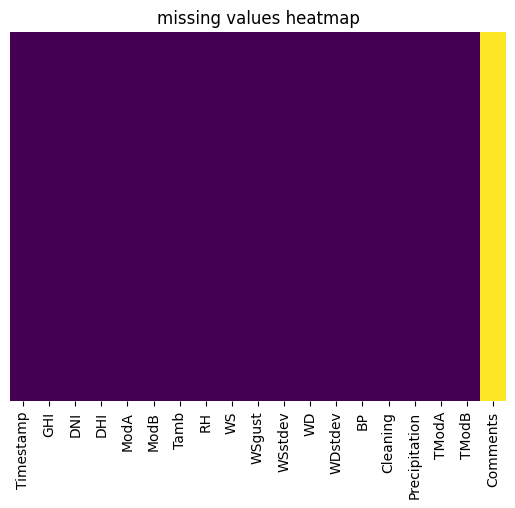

In [8]:
utils.draw_heat_map_outliner(df, "missing values heatmap")

## outliers

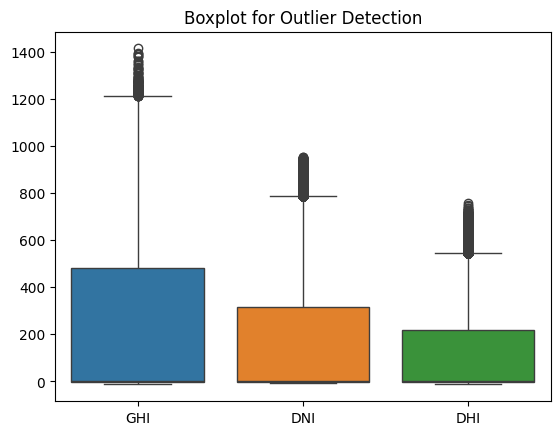

In [4]:
cols = ['GHI', "DNI", "DHI"]
utils.draw_boxplots(df, cols, "Boxplot for Outlier Detection")

In [3]:
cols = ['GHI', "DNI", "DHI"]
outliers = utils.find_outliers_iqr(df, cols)
print(outliers)     

               Timestamp     GHI    DNI    DHI    ModA    ModB  Tamb    RH  \
671     2021-08-09 11:12  1274.0  698.8  615.2  1210.3  1210.3  30.1  69.6   
674     2021-08-09 11:15  1349.0  771.8  618.0  1281.5  1281.5  30.9  67.1   
676     2021-08-09 11:17  1334.0  751.9  620.0  1267.3  1267.3  31.1  67.0   
849     2021-08-09 14:10  1253.0  714.8  552.5  1156.0  1155.0  31.0  64.2   
850     2021-08-09 14:11  1324.0  813.0  532.3  1218.0  1217.0  31.0  62.9   
...                  ...     ...    ...    ...     ...     ...   ...   ...   
524921  2022-08-08 12:42   723.9  161.8  554.7   678.7   676.7  30.7  70.9   
524937  2022-08-08 12:58   687.3  134.5  546.3   644.8   642.2  30.3  72.7   
524938  2022-08-08 12:59   680.5  129.4  544.3   643.6   640.7  30.3  73.4   
524964  2022-08-08 13:25   683.3  131.4  545.4   644.2   636.0  30.8  69.7   
524965  2022-08-08 13:26   690.6  137.9  546.6   650.0   641.9  30.7  71.0   

         WS  WSgust  WSstdev     WD  WDstdev   BP  Cleaning  Pr

In [4]:
sensor_reading_cols = ['ModA', 'ModB']
outliers = utils.find_outliers_iqr(df, sensor_reading_cols)
print(outliers)   
    

               Timestamp     GHI    DNI    DHI    ModA    ModB  Tamb    RH  \
671     2021-08-09 11:12  1274.0  698.8  615.2  1210.3  1210.3  30.1  69.6   
674     2021-08-09 11:15  1349.0  771.8  618.0  1281.5  1281.5  30.9  67.1   
676     2021-08-09 11:17  1334.0  751.9  620.0  1267.3  1267.3  31.1  67.0   
850     2021-08-09 14:11  1324.0  813.0  532.3  1218.0  1217.0  31.0  62.9   
5019    2021-08-12 11:40  1324.0  675.6  659.6  1271.0  1271.0  29.1  75.4   
...                  ...     ...    ...    ...     ...     ...   ...   ...   
522024  2022-08-06 12:25  1229.0  764.2  455.8  1138.0  1133.0  30.2  69.2   
522046  2022-08-06 12:47  1218.0  619.7  580.5  1130.0  1128.0  30.3  70.7   
522067  2022-08-06 13:08  1218.0  724.9  477.8  1137.0  1133.0  30.5  67.3   
522074  2022-08-06 13:15  1262.0  772.4  475.8  1166.0  1153.0  31.1  66.0   
522075  2022-08-06 13:16  1289.0  758.1  519.2  1191.0  1179.0  31.4  65.9   

         WS  WSgust  WSstdev     WD  WDstdev   BP  Cleaning  Pr

In [5]:
wind_speed_data_cols = ['WS', 'WSgust']
outliers = utils.find_outliers_iqr(df, wind_speed_data_cols)
print(outliers)  
    

               Timestamp    GHI  DNI    DHI   ModA   ModB  Tamb    RH   WS  \
2209    2021-08-10 12:50  360.2  0.7  359.9  339.9  344.2  31.6  63.0  6.4   
2879    2021-08-11 00:00   -2.0 -0.3   -1.7    0.0    0.0  24.7  93.7  6.9   
2950    2021-08-11 01:11   -1.2 -0.2   -0.6    0.0    0.0  23.9  96.2  6.6   
2957    2021-08-11 01:18   -1.2 -0.1   -0.6    0.0    0.0  23.5  95.6  6.4   
2958    2021-08-11 01:19   -1.2 -0.2   -0.6    0.0    0.0  23.5  94.9  7.9   
...                  ...    ...  ...    ...    ...    ...   ...   ...  ...   
525143  2022-08-08 16:24    4.5 -0.1    4.5    5.8    5.7  21.9  99.0  6.7   
525150  2022-08-08 16:31    4.7 -0.2    4.8    5.9    5.8  22.0  99.1  6.7   
525151  2022-08-08 16:32    4.7 -0.1    4.8    6.0    5.9  22.0  99.1  7.3   
525155  2022-08-08 16:36    4.8  0.0    4.9    6.0    5.9  22.0  99.1  6.9   
525159  2022-08-08 16:40    4.9 -0.1    5.0    5.9    5.7  22.1  99.2  6.3   

        WSgust  WSstdev     WD  WDstdev   BP  Cleaning  Precipi

## Z-scores

In [5]:
req_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
z_scores = pd.DataFrame()
for col in req_cols:
    mean = df[col].mean()
    std = df[col].std()
    z_scores[col] = (df[col] - mean) / std
    
outliers= abs(z_scores> 3)
outliers_rows = df[outliers.any(axis=1)]
print(outliers_rows)

               Timestamp     GHI    DNI    DHI    ModA    ModB  Tamb    RH  \
670     2021-08-09 11:11   836.0  235.0  610.6   778.8   783.8  30.3  68.2   
671     2021-08-09 11:12  1274.0  698.8  615.2  1210.3  1210.3  30.1  69.6   
672     2021-08-09 11:13   938.0  340.1  612.8   891.1   891.1  30.4  68.4   
673     2021-08-09 11:14   718.5  126.8  593.2   682.6   682.6  30.6  68.2   
674     2021-08-09 11:15  1349.0  771.8  618.0  1281.5  1281.5  30.9  67.1   
...                  ...     ...    ...    ...     ...     ...   ...   ...   
525141  2022-08-08 16:22     4.6   -0.1    4.6     6.1     5.9  21.9  99.0   
525142  2022-08-08 16:23     4.6    0.2    4.6     5.9     5.8  21.9  99.0   
525143  2022-08-08 16:24     4.5   -0.1    4.5     5.8     5.7  21.9  99.0   
525151  2022-08-08 16:32     4.7   -0.1    4.8     6.0     5.9  22.0  99.1   
525155  2022-08-08 16:36     4.8    0.0    4.9     6.0     5.9  22.0  99.1   

         WS  WSgust  WSstdev     WD  WDstdev   BP  Cleaning  Pr

# alternative way with numpy

In [6]:
mean = df[req_cols].mean()
std = df[req_cols].std()
z_scores =  (df[req_cols] - mean) / std
z_scores

,GHI,DNI,DHI,ModA,ModB,WS,WSgust
0,-0.730101,-0.639590,-0.733872,-0.723748,-0.723087,-1.322830,-1.187310
1,-0.729799,-0.639590,-0.733872,-0.723748,-0.723087,-1.322830,-1.384440
2,-0.729799,-0.639590,-0.733872,-0.723748,-0.723087,-1.135735,-0.842333
3,-0.729799,-0.639208,-0.733242,-0.723748,-0.723087,-1.198100,-1.039463
4,-0.729497,-0.639208,-0.733242,-0.723748,-0.723087,-1.260465,-1.039463
...,...,...,...,...,...,...,...
525595,-0.743087,-0.639208,-0.764120,-0.723748,-0.723087,-1.135735,-0.842333
525596,-0.743087,-0.639208,-0.763489,-0.723748,-0.723087,-1.198100,-1.039463
525597,-0.743087,-0.639208,-0.763489,-0.723748,-0.723087,-0.948641,-0.842333
525598,-0.743087,-0.639208,-0.763489,-0.723748,-0.723087,-0.761546,-0.743768


In [7]:
outliers = (abs(z_scores) > 3)
print(outliers)

          GHI    DNI    DHI   ModA   ModB     WS  WSgust
0       False  False  False  False  False  False   False
1       False  False  False  False  False  False   False
2       False  False  False  False  False  False   False
3       False  False  False  False  False  False   False
4       False  False  False  False  False  False   False
...       ...    ...    ...    ...    ...    ...     ...
525595  False  False  False  False  False  False   False
525596  False  False  False  False  False  False   False
525597  False  False  False  False  False  False   False
525598  False  False  False  False  False  False   False
525599  False  False  False  False  False  False   False

[525600 rows x 7 columns]


In [8]:
outliers_rows = df[outliers.any(axis=1)]
print(outliers_rows)

               Timestamp     GHI    DNI    DHI    ModA    ModB  Tamb    RH  \
670     2021-08-09 11:11   836.0  235.0  610.6   778.8   783.8  30.3  68.2   
671     2021-08-09 11:12  1274.0  698.8  615.2  1210.3  1210.3  30.1  69.6   
672     2021-08-09 11:13   938.0  340.1  612.8   891.1   891.1  30.4  68.4   
673     2021-08-09 11:14   718.5  126.8  593.2   682.6   682.6  30.6  68.2   
674     2021-08-09 11:15  1349.0  771.8  618.0  1281.5  1281.5  30.9  67.1   
...                  ...     ...    ...    ...     ...     ...   ...   ...   
525141  2022-08-08 16:22     4.6   -0.1    4.6     6.1     5.9  21.9  99.0   
525142  2022-08-08 16:23     4.6    0.2    4.6     5.9     5.8  21.9  99.0   
525143  2022-08-08 16:24     4.5   -0.1    4.5     5.8     5.7  21.9  99.0   
525151  2022-08-08 16:32     4.7   -0.1    4.8     6.0     5.9  22.0  99.1   
525155  2022-08-08 16:36     4.8    0.0    4.9     6.0     5.9  22.0  99.1   

         WS  WSgust  WSstdev     WD  WDstdev   BP  Cleaning  Pr

# Drop missing values

In [ ]:
df = df.dropna(subset = req_cols)

# Export cleaned DataFrame to data

In [ ]:
df.to_csv("../data/benin-malanville_clean.csv")

# Impute with median value

In [19]:
#python way
req_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
for col in req_cols:
    median = df[col].median()
    df[col] = df[col].fillna(median)

In [4]:
#better approach
req_cols = ['GHI', 'DNI', 'DHI', 'ModA', 'ModB', 'WS', 'WSgust']
median = df[req_cols].median()
df[req_cols] = df[req_cols].fillna(median)

# Export cleaned DataFrame to data

In [10]:
df.to_csv("../data/benin-malanville_clean.csv")

# Time Series Analysis

In [ ]:
time_selected_cols = ['GHI', 'DNI', 'DHI', 'Tamb']
plt.figure(figsize=(8, 4))

df_sampled = df.iloc[::10, :]

for col in time_selected_cols:
    plt.plot(df_sampled['Timestamp'], df_sampled[col], label=col)

plt.xlabel("Timestamp")
plt.ylabel("Values")
plt.title('GHI, DNI, DHI, Tamb vs. Timestamp')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


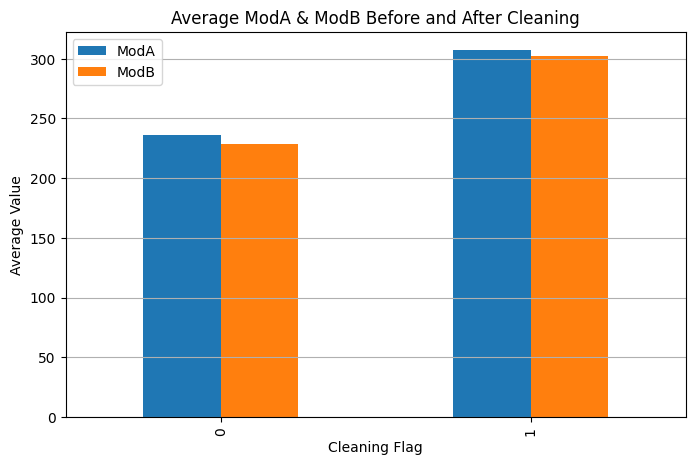

In [21]:
clean_avg = df.groupby('Cleaning')[['ModA', 'ModB']].mean()

clean_avg.plot(kind='bar', figsize=(8, 5))
plt.title('Average ModA & ModB Before and After Cleaning')
plt.ylabel('Average Value')
plt.xlabel('Cleaning Flag')
plt.grid(axis='y')
plt.show()

# correlation heatmap

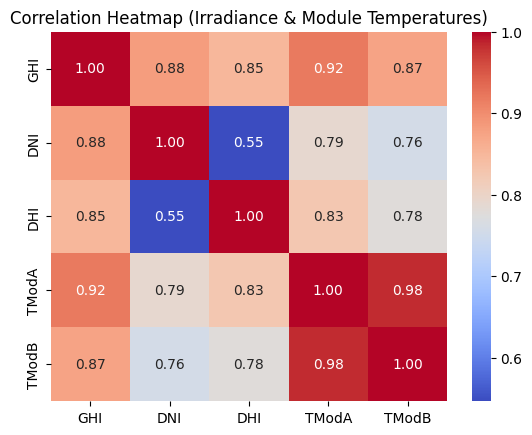

In [4]:
corr_cols = ['GHI', 'DNI', 'DHI', 'TModA', 'TModB']
utils.draw_correlation_heatmap(df,"Correlation Heatmap (Irradiance & Module Temperatures)", corr_cols )

## scatter plots

# WS vs GHI

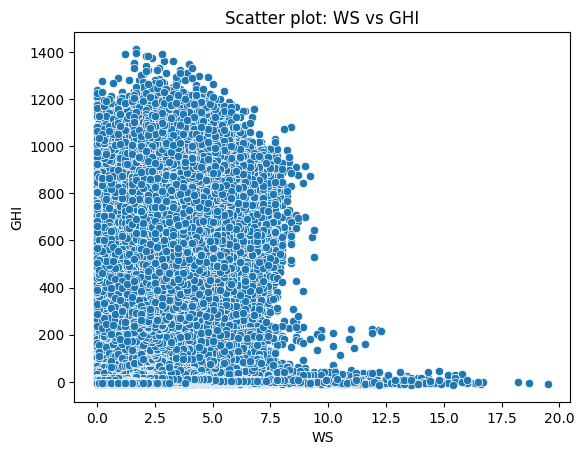

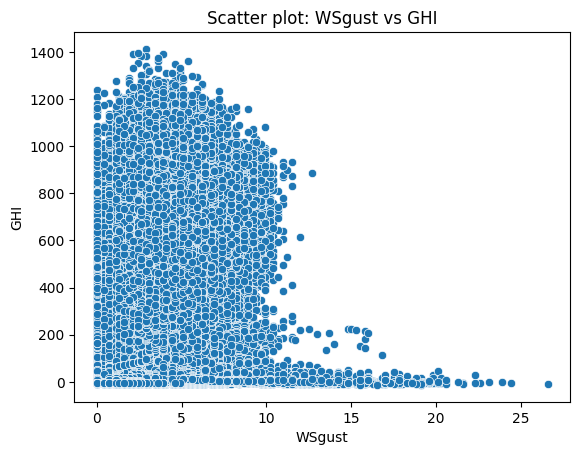

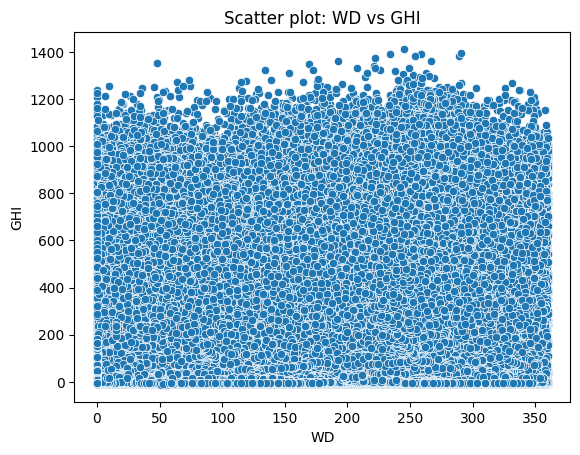

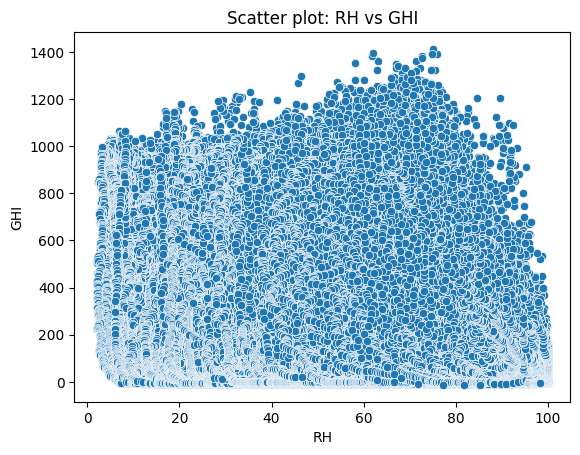

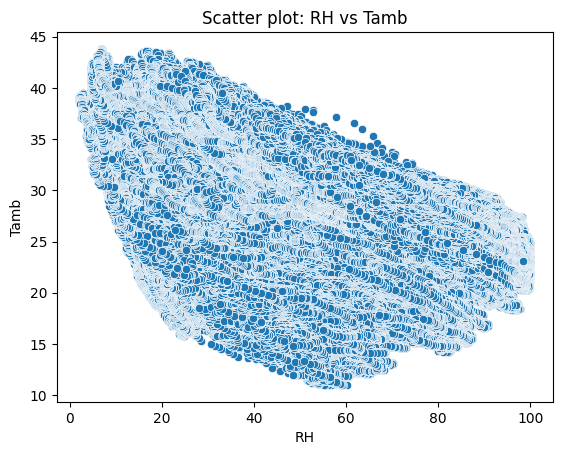

In [4]:
def pltscatter():
    cols = ['WS', 'WSgust','WD', 'RH']
    
    for col in cols:
        utils.draw_scatterplot(df, col, "GHI")

    utils.draw_scatterplot(df, "RH", "Tamb")
        
pltscatter()

# Wind & Distribution Analysis

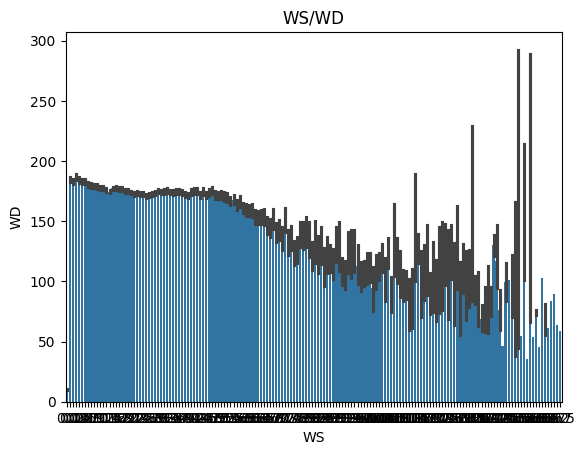

In [8]:
utils.draw_barplot(df, "WS", "WD", "WS/WD")

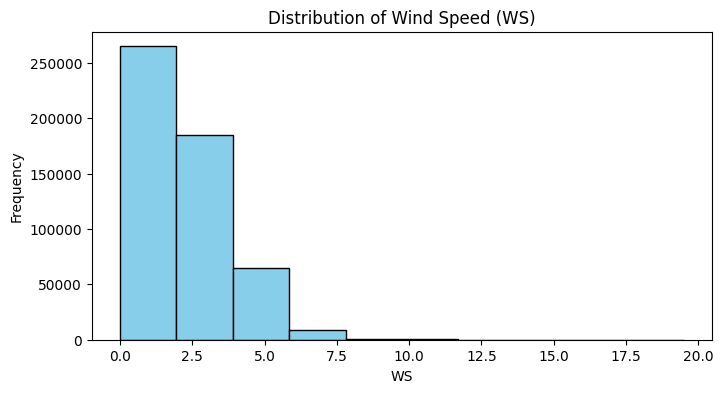

In [5]:
utils.draw_histogram(df, "WS", "Distribution of Wind Speed (WS)")

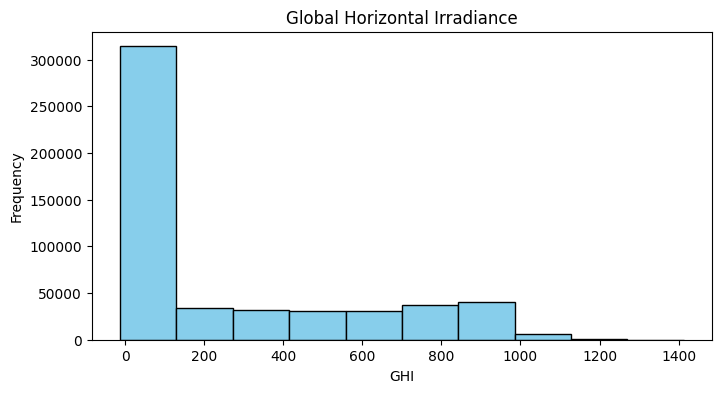

In [6]:
utils.draw_histogram(df, "GHI", "Global Horizontal Irradiance")

# Temperature Analysis

In [8]:
print(df[['RH', 'Tamb', 'GHI', 'DNI', 'DHI']].corr())

            RH      Tamb       GHI       DNI       DHI
RH    1.000000 -0.414842 -0.360029 -0.373475 -0.285018
Tamb -0.414842  1.000000  0.547513  0.467584  0.503925
GHI  -0.360029  0.547513  1.000000  0.882376  0.849989
DNI  -0.373475  0.467584  0.882376  1.000000  0.546602
DHI  -0.285018  0.503925  0.849989  0.546602  1.000000


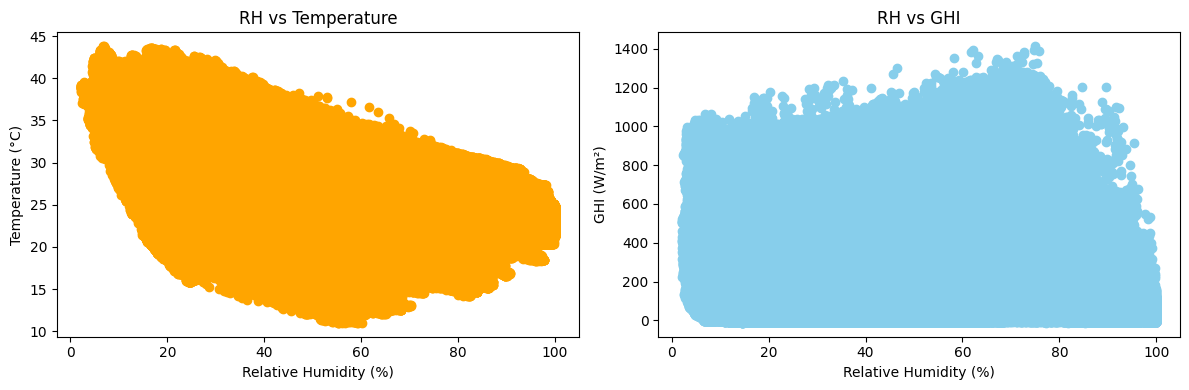

In [11]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.scatter(df['RH'], df['Tamb'], color='orange')
plt.xlabel("Relative Humidity (%)")
plt.ylabel("Temperature (°C)")
plt.title("RH vs Temperature")

plt.subplot(1,2,2)
plt.scatter(df['RH'], df['GHI'], color='skyblue')
plt.xlabel("Relative Humidity (%)")
plt.ylabel("GHI (W/m²)")
plt.title("RH vs GHI")

plt.tight_layout()
plt.show()

# Bubble Chart

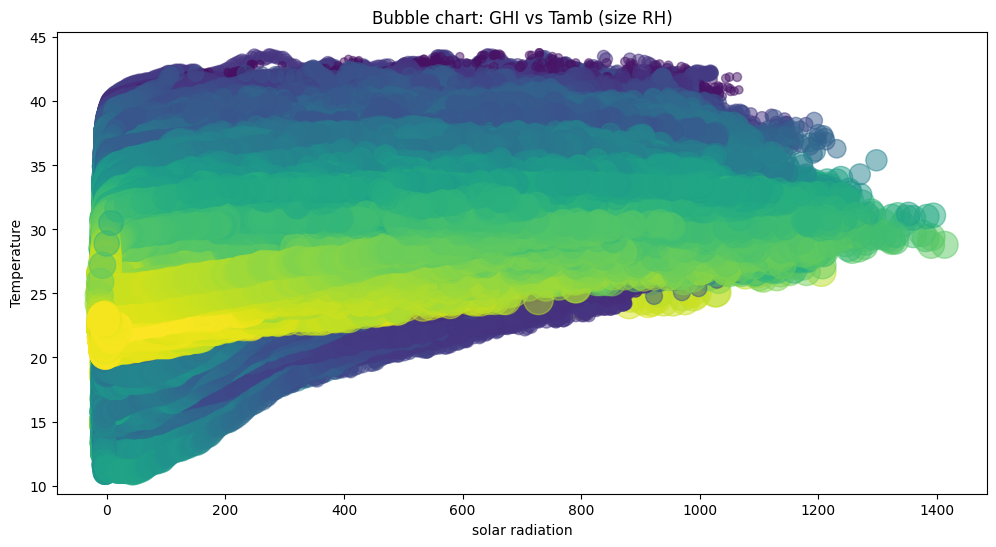

In [3]:
utils.draw_bubbleplot(df, 'GHI','Tamb','RH' )